# Map Reduce
## Review
We're building up to a multi-agent research assistant that ties together all of the modules from this course.

We just covered parallelization (`parallelization.ipynb`) and sub-graph (`sub_graph.ipynb`).

## Goals
Now, we are going to cover map reduce.

# Problem
Map-reduce operations are essential for efficient task decomposition and parallel processing. It has two phases:
1. `Map` - Break a task into smaller sub-tasks, processing each sub-task in parallel.
2. `Reduce` - Aggregate the results across all of the completed, parallelized sub-tasks.

In [10]:
# Import libraries
import os
import re 
import json
import operator

from dotenv import load_dotenv
from typing import Annotated
from typing_extensions import TypedDict
from pydantic import BaseModel

from langchain_openai import ChatOpenAI
from langgraph.types import Send
from langchain_core.messages import SystemMessage, HumanMessage

# Load env variable for API Key
load_dotenv()
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL")

# Prompt we will use
subjects_prompt = """
    Generate a list of 3 sub-topics that are all related to this overall topic: {topic}.
"""
joke_prompt = """
    Generate a joke about {subject}.
"""
best_joke_prompt = """
    Below are a bunch of jokes about {topic}. Select the best one!
"""

# Set the Chat Model
llm = ChatOpenAI(
    model="deepseek-v4-pro",  # Or "deepseek-v4-flash" for a faster option
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    temperature=0
)

def get_structured_response_native(llm, pydantic_model, prompt):
    """
    Use DeepSeek's native response format.
    """
    schema = pydantic_model.model_json_schema()
    system_message = SystemMessage(
        content=f"""
            You are a helpful assistant that always responds in JSON format.
            The response must match this JSON schema: {json.dumps(schema, indent=2)}

            Do not include any other text, explanation, or markdown formatting.
            Only respond with valid JSON that matches the schema.
        """
    )
    human_message = HumanMessage(content=prompt)
    response = llm.invoke([system_message, human_message])
    content = response.content
    content = re.sub(r'```json\s*|```\s*', '', content)
    data = json.loads(content)
    return pydantic_model(**data)

## State
### Parallelizing Joke Generation
First, let's define the entry point of the graph that will:
- Take a user input topic.
- Produce a list of joke topics from it.
- Send each joke topic to our above joke generation node.

Our state has a `jokes` key, which will accumulate jokes from parallelized joke generation.

Here is the magic: We use `Send` to create a joke for each subject. This is very useful. It can automatically parallelized joke generation for any number of subjects.
- `generate_joke`: the name of the node in the graph.
- `{"subject": s}`: the state to send.

`Send` allow you to pass any state that you want to `generate_joke`. It does not have to align with `OverallState`.

In [11]:
class Subjects(BaseModel):
    subjects: list[str]

class BestJoke(BaseModel):
    id: int

class OverallState(TypedDict):
    topic: str
    subjects: list
    jokes: Annotated[list, operator.add]
    best_selected_joke: str

def generate_topics(state: OverallState):
    prompt = subjects_prompt.format(topic=state["topic"])
    response = get_structured_response_native(llm, Subjects, prompt)
    return {"subjects": response.subjects}

def continue_to_jokes(state: OverallState):
    return [Send("generate_joke", {"subject": s}) for s in state["subjects"]]

### Joke Generation (Map)
Now, we just define a node that will create our jokes, `generate_joke`. We write them back out to `jokes` in `OverallState`.

This key has a reducer that will combine lists.

### Best Joke Selection (Reduce)
Now, we add logic to pick the best joke.

In [12]:
class JokeState(TypedDict):
    subject: str

class Joke(BaseModel):
    joke: str

def generate_joke(state: JokeState):
    prompt = joke_prompt.format(subject=state["subject"])
    response = get_structured_response_native(llm, Joke, prompt)
    return {"jokes": [response.joke]}

def best_joke(state: OverallState):
    jokes = "\n\n".join(state["jokes"])
    prompt = best_joke_prompt.format(topic=state["topic"], jokes=jokes)
    response = get_structured_response_native(llm, BestJoke, prompt)
    return {"best_selected_joke": state["jokes"][response.id]}

## Compile

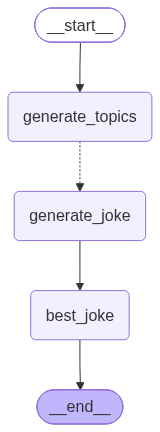

{'generate_topics': {'subjects': ['Mammals', 'Birds', 'Reptiles']}}
{'generate_joke': {'jokes': ["Why do birds fly south in the winter? Because it's too far to walk!"]}}
{'generate_joke': {'jokes': ['Why are snakes good at math? Because they can multiply by hisssss.']}}
{'generate_joke': {'jokes': ["What do you call a mammal that can't stop telling jokes? A stand-up otter!"]}}
{'best_joke': {'best_selected_joke': "What do you call a mammal that can't stop telling jokes? A stand-up otter!"}}


In [13]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Build the graph
builder = StateGraph(OverallState)
builder.add_node("generate_topics", generate_topics)
builder.add_node("generate_joke", generate_joke)
builder.add_node("best_joke", best_joke)

# Logic
builder.add_edge(START, "generate_topics")
builder.add_conditional_edges("generate_topics", continue_to_jokes, ["generate_joke"])
builder.add_edge("generate_joke", "best_joke")
builder.add_edge("best_joke", END)

# Compile
app = builder.compile()
display(Image(app.get_graph().draw_mermaid_png()))

# Call the graph
for s in app.stream({"topic": "animals"}):
    print(s)